Длина sequence: 32
Длина notation: 32


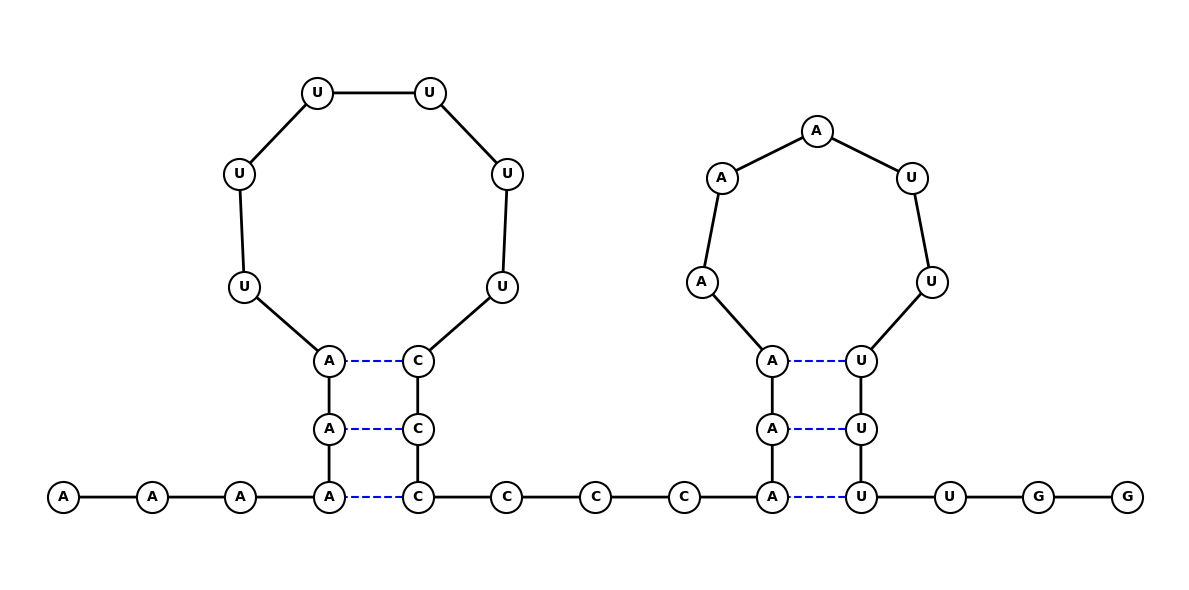

Длина sequence: 62
Длина notation: 62


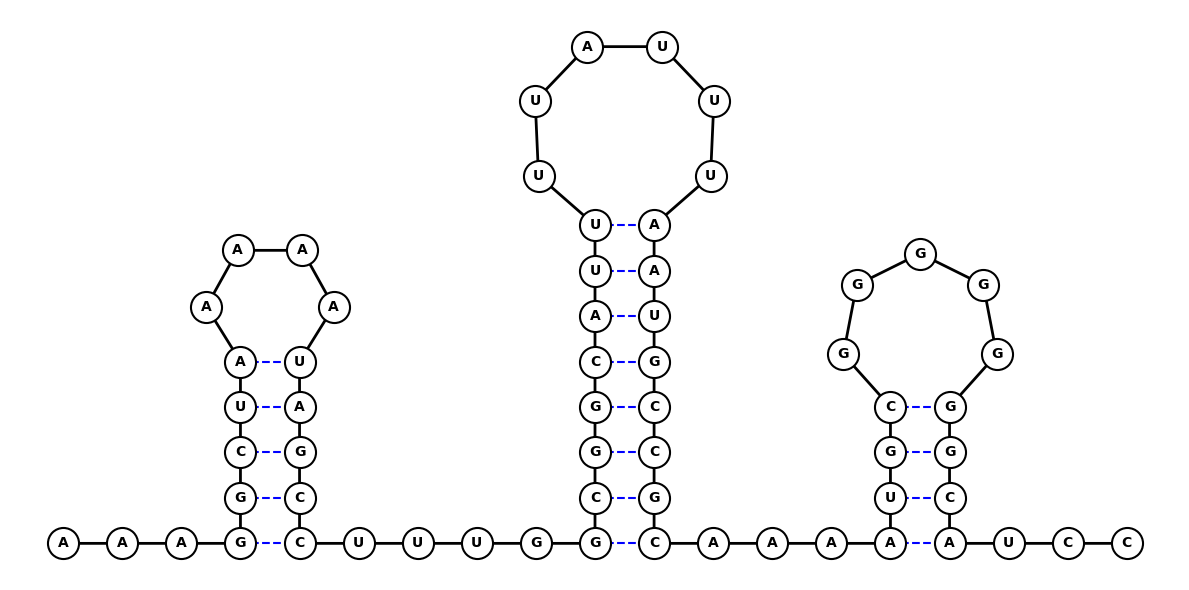

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def check_not(notation):
    stack = []
    if notation.count("(") + notation.count(")") == 0:
        return False
    
    for item in notation:
        if item == "(":
            stack.append("(")
        elif item == ")":
            if not stack:
                return False
            stack.pop()
        elif item == ".":
            continue
        else:
            return False
        
    return len(stack) == 0


def parse_structures(notation):
    """
    Разбирает нотацию на блоки:
    - ('lenght', длина)
    - ('loop', длина стебля, длина петли)
    """
    structures = []
    i = 0
    n = len(notation)
    
    while i < n:                                    
        if notation[i] == '.':
            free_nucl_len = 0
            while i < n and notation[i] == '.':
                free_nucl_len += 1
                i += 1
            structures.append(('lenght', free_nucl_len))
            
        elif notation[i] == '(':          
            steb_len = 0
            while i < n and notation[i] == '(':
                steb_len += 1
                i += 1

            loop_len = 0        
            while i < n and notation[i] == '.':
                loop_len += 1
                i += 1

            right_steb = 0                 
            while i < n and notation[i] == ')':
                right_steb += 1
                i += 1
                
            structures.append(('loop', steb_len, loop_len))
            
    return structures


def draw_rna(sequence, notation):
    if len(sequence) != len(notation):
        print("Ошибка! Длина последовательности и нотации не совпадает.")
        print(f"Длина sequence: {len(sequence)}, длина notation: {len(notation)}") 
        return
        
    if not check_not(notation):
        print("Ошибка! Нотация некорректна.")
        return
        
    blocks = parse_structures(notation)  
    

    x_coords = []
    y_coords = []
    h_bonds = []  
    
    dist_horisont = 1.3  
    dist_up = 1.0       
    
    current_x = 0.0     
    nuc_index = 0      
    
   
    for block in blocks:
        if block[0] == 'lenght':              
            free_nucl_len = block[1]

            for _ in range(free_nucl_len):
                x_coords.append(current_x)
                y_coords.append(0.0)
                current_x += dist_horisont
                nuc_index += 1
                
        elif block[0] == 'loop':
            steb_len, loop_len = block[1], block[2]
            
            left_steb_x, left_steb_y = [], []
            right_steb_x, right_steb_y = [], []
            
            start_x = current_x
            
            #Левая половина стебля
            for i in range(steb_len):
                left_steb_x.append(start_x)
                left_steb_y.append(i * dist_up)
                
            #Правая половина стебля 
            end_x = start_x + dist_horisont
            for i in range(steb_len):
                right_steb_x.append(end_x)
                right_steb_y.append(i * dist_up)
                
            # Y-координата верхушки стебля
            Y_top = (steb_len - 1) * dist_up  
            
            radius = max(1.1, loop_len * 0.35)   
            
            y_center = Y_top + np.sqrt(radius**2 - (dist_horisont / 2)**2)
            
            beta = np.arccos((dist_horisont / 2) / radius)
            theta_start = np.pi + beta  
            theta_end = -beta           
            
            # Равномерное распределение углов для нуклеотидов петли
            all_angles = np.linspace(theta_start, theta_end, loop_len + 2)
            loop_angles = all_angles[1:-1]
            
            loop_x, loop_y = [], []
            for angle in loop_angles:
                x = (start_x + dist_horisont / 2) + radius * np.cos(angle)
                y = y_center + radius * np.sin(angle)
                loop_x.append(x)
                loop_y.append(y)
                
            
            # 1 - Левый стебель (снизу вверх)
            # 2 - Петля (по дуге)
            # 3 - Правый стебель (сверху вниз)
            
            for i in range(steb_len):
                l_idx = nuc_index + i      
                r_idx = nuc_index + steb_len + loop_len + (steb_len - 1 - i)
                h_bonds.append((l_idx, r_idx))
                
            x_coords.extend(left_steb_x + loop_x + right_steb_x[::-1])    
            y_coords.extend(left_steb_y + loop_y + right_steb_y[::-1])
            
           
            current_x = end_x + dist_horisont
            nuc_index += (steb_len * 2 + loop_len)

    #ВИЗУАЛИЗАЦИЯ
    plt.figure(figsize=(12, 6))
    
    #линия, соединяющая все нуклеотиды последовательно
    plt.plot(x_coords, y_coords, color='black', linewidth=2, zorder=1)
    
    #водородные связи
    for left, right in h_bonds:
        plt.plot([x_coords[left], x_coords[right]], [y_coords[left], y_coords[right]], 
                 color='blue', linestyle='--', linewidth=1.5, zorder=1)
                 
    plt.scatter(x_coords, y_coords, s=500, c='white', edgecolors='black', linewidths=1.5, zorder=2)
    
    for i in range(len(sequence)):
        plt.text(x_coords[i], y_coords[i], sequence[i], 
                 ha='center', va='center', fontsize=10, fontweight='bold', zorder=3)
                 
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

sequence = "AAAAAAUUUUUUCCCCCCAAAAAAUUUUUUGG"
notation = "...(((......)))...(((.....)))..."


print(f"Длина sequence: {len(sequence)}")
print(f"Длина notation: {len(notation)}")

draw_rna(sequence, notation)

sequence2 = "AAAGGCUAAAAAUAGCCUUUGGCGGCAUUUUAUUUAAUGCCGCAAAAUGCGGGGGGGCAUCC"
notation2 ="...(((((....)))))....((((((((......))))))))...((((.....))))..."


print(f"Длина sequence: {len(sequence2)}")
print(f"Длина notation: {len(notation2)}")

draw_rna(sequence2, notation2)

### 